# completador de palavras

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

In [ ]:
url ='https://github.com/allanspadini/curso-tensorflow-proxima-palavra/raw/main/dados/train.zip'

df = pd.read_csv(url, header=None, names=['ClassIndex', 'Título', 'Descrição'])

df['text'] = df['Título'] + ' ' + df['Descrição']

df.text

,text
0,Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new..."
...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...
119996,Renteria signing a top-shelf deal Red Sox gene...
119997,Saban not going to Dolphins yet The Miami Dolp...
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...


In [ ]:
random.seed(44)
df_sample = df.sample(n=1000)

VOCAB_SIZE = 20000
SEQUENCE_MAX = 50

corpus = df_sample['text'].tolist()

len(corpus)

1000

In [ ]:
vectorizer = TextVectorization(max_tokens=VOCAB_SIZE,
                               output_sequence_length=SEQUENCE_MAX,
                               output_mode='int')

vectorizer.adapt(corpus)

In [ ]:
tokenizes_corpus = vectorizer(corpus)

In [ ]:
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [ ]:
input_sequences = []

for token_list in tokenizes_corpus:
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

input_sequences

[<tf.Tensor: shape=(2,), dtype=int64, numpy=array([5427, 3482])>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([5427, 3482,  715])>,
 <tf.Tensor: shape=(4,), dtype=int64, numpy=array([5427, 3482,  715,    9])>,
 <tf.Tensor: shape=(5,), dtype=int64, numpy=array([5427, 3482,  715,    9,  395])>,
 <tf.Tensor: shape=(6,), dtype=int64, numpy=array([5427, 3482,  715,    9,  395,  127])>,
 <tf.Tensor: shape=(7,), dtype=int64, numpy=array([5427, 3482,  715,    9,  395,  127,   44])>,
 <tf.Tensor: shape=(8,), dtype=int64, numpy=array([5427, 3482,  715,    9,  395,  127,   44,  334])>,
 <tf.Tensor: shape=(9,), dtype=int64, numpy=array([5427, 3482,  715,    9,  395,  127,   44,  334,   72])>,
 <tf.Tensor: shape=(10,), dtype=int64, numpy=array([5427, 3482,  715,    9,  395,  127,   44,  334,   72, 3824])>,
 <tf.Tensor: shape=(11,), dtype=int64, numpy=array([5427, 3482,  715,    9,  395,  127,   44,  334,   72, 3824,  809])>,
 <tf.Tensor: shape=(12,), dtype=int64, numpy=
 array([5427, 3482,  7

In [ ]:
def prepare_sequences(sequences):
    """
    Prepara as sequências para o modelo, removendo zeros à direita, adicionando padding à esquerda, truncado sequências longas e removendo sequências repetidas.

    Args:
        sequences: Um array de sequências (listas ou arrays NumPy).

    Returns:
        Um array NumPy 2D com as sequências preparadas.
    """

    # Remover zeros à direita de cada sequência
    sequences_without_trailing_zeros = []
    for seq in sequences:
        # Convert EagerTensor to NumPy array
        seq_np = seq.numpy()
        last_nonzero_index = np.argmax(seq_np[::-1] != 0)
        if last_nonzero_index == 0 and seq_np[-1] == 0:
            sequences_without_trailing_zeros.append(np.array([0]))
        else:
            sequences_without_trailing_zeros.append(seq_np[:-last_nonzero_index or None])

    # Remover sequências repetidas
    unique_sequences = []
    for seq in sequences_without_trailing_zeros:
        if seq.tolist() not in unique_sequences:  # Verifica se a sequência já está na lista
            unique_sequences.append(seq.tolist())  # Adiciona à lista se for única

    # Encontrar o comprimento máximo das sequências sem zeros à direita
    max_sequence_len = max(len(seq) for seq in unique_sequences)

    # Adicionar padding à esquerda para garantir o mesmo comprimento
    padded_sequences = pad_sequences(unique_sequences, maxlen=max_sequence_len, padding='pre', truncating='post')

    return padded_sequences

In [ ]:
input_sequences_prepared = prepare_sequences(input_sequences)
print(input_sequences_prepared)

[[   0    0    0 ...    0 5427 3482]
 [   0    0    0 ... 5427 3482  715]
 [   0    0    0 ... 3482  715    9]
 ...
 [   0    0 3409 ...  679   13    5]
 [   0 3409   19 ...   13    5   48]
 [3409   19  242 ...    5   48  862]]


In [ ]:
x = input_sequences_prepared[:,:-1]
y = input_sequences_prepared[:,-1]

y

array([3482,  715,    9, ...,    5,   48,  862], dtype=int32)

In [ ]:
y = tf.keras.utils.to_categorical(y, num_classes=VOCAB_SIZE)
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Treinamento com Deep Learning

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=False
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [ ]:
history = model.fit(x,y,
                    epochs=100,
                    verbose=1,
                    batch_size=64)

Epoch 1/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.0327 - loss: 9.1098
Epoch 2/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.0475 - loss: 7.5119
Epoch 3/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.0636 - loss: 7.2497
Epoch 4/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.0733 - loss: 7.0309
Epoch 5/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.0852 - loss: 6.7442
Epoch 6/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.0942 - loss: 6.5056
Epoch 7/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.1078 - loss: 6.2278
Epoch 8/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.1210 - loss: 5.9662
Epoch 9/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.1342 - loss: 5.7518
Epoch 10/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.1535 - loss: 5.4972
Epoch 11/100
558/558 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.1653 - loss: 5.2720
Epoch 12/100
558/55

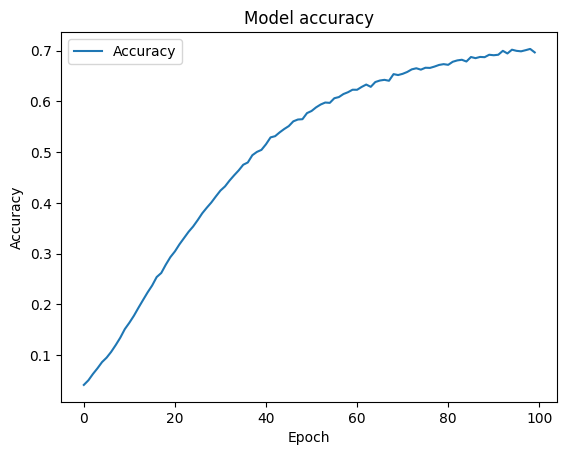

In [ ]:
plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Accuracy'])
plt.show()

Tentar prever as próximas 3 palavras mais próximas

In [ ]:
def predict_next_word(text, model, vectorizer, max_sequence_length, top_k=3):
  tokenized_text = vectorizer([text])
  tokenized_text = np.squeeze(tokenized_text)

  padded_text = pad_sequences([tokenized_text], maxlen=max_sequence_length,
                              padding='pre', truncating='post')

  predicted_probs = model.predict(padded_text, verbose=0)[0]

  top_k_indices = np.argsort(predicted_probs)[-top_k:][::-1]

  predicted_words = [vectorizer.get_vocabulary()[index] for index in top_k_indices]

  return predicted_words

In [ ]:
# Teste com valor qualquer:

#text = "Apple needs to make the iPhone"
text = "The FBI is warning consumers against using public phone charging stations in order to"
#text = 'Making measures for a sustainable future An analyzing tool from Sandvik Coromant helps customers reduce their energy consumption and carbon emissions based on data.'

preditec_next_word = predict_next_word(text, model, vectorizer, SEQUENCE_MAX, top_k=3)
print(preditec_next_word)

model.save('model_best.keras')

['report', 'shares', 'next']


# Pontos importantes

* Criar e configurar uma aplicação web com Streamlit.
* Implementar a função main para gerenciar a lógica da aplicação.
* Carregar e inicializar um modelo pré-treinado e o vectorizer.
* Integrar a função predictNextWords para prever próximas palavras.
* Utilizar componentes de interface do Streamlit, como st.title, st.info, st.success e st.warning.
* Configurar um arquivo requirements.txt para listar as dependências do projeto.
* Executar o processo de deploy da aplicação utilizando a plataforma Streamlit Community Cloud.
* Compreender a importância da amostragem de dados para reduzir o volume de informação a ser processada.
* Implementar a tokenização do corpus textual e converter palavras em tokens numéricos utilizando o TextVectorization do TensorFlow.
* Criar sequências de texto para treinar a rede neural, utilizando a função pad_sequences para padronizar o tamanho.
* Dividir sequências de texto em X e Y para transformação do problema de predição em classificação multiclasse e usar a função tf.keras.utils.to_categorical para one-hot encoding.
* Adotar redes neurais LSTM para classificação multiclasse, ajustando o número de neurônios e utilizando a camada BatchNormalization.
* Treinar a rede neural definindo hiperparâmetros como número de épocas e batch_size, e validar a evolução da acurácia com Matplotlib.
* Implementar uma função para prever próximas palavras em uma sequência de texto usando o vetorizar e um modelo treinado.
* Salvar um modelo treinado para uso posterior utilizando a função model.save e explorar o processo de disponibilizá-lo em plataformas de armazenamento.